## Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
rfm = pd.read_csv("~/Customer-Segmentation-and-Churn-Analysis/data/rfm.csv")

## Define Churn
Customers are classified as churned if they exhibit high inactivity (Recency > 180 days) and low purchase frequency (Frequency < 2), indicating reduced engagement.

In [14]:
rfm['Churn'] = ((rfm['Recency'] > 180) & (rfm['Frequency'] < 2)).astype(int)

In [15]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Segment,Cluster,Segment_KMeans,Churn
0,12346.0,325,1,77183.60,1,1,5,115,Others,3,Loyal,1
1,12347.0,1,7,4310.00,5,5,5,555,Champion,0,Average,0
2,12348.0,74,4,1797.24,2,4,4,244,At Risk,0,Average,0
3,12349.0,18,1,1757.55,4,1,4,414,Others,0,Average,0
4,12350.0,309,1,334.40,1,1,2,112,Others,1,At Risk,1


## Churn Analysis by Segment

In [16]:
# Show average churn rate per K-Means segment
rfm.groupby('Segment_KMeans')['Churn'].mean()

Segment_KMeans
At Risk     0.578257
Average     0.000000
Champion    0.000000
Loyal       0.004902
Name: Churn, dtype: float64

The "At Risk" segment has the highest churn rate and should be prioritized for retention efforts.

## Feature Preparation

In [10]:
# Define features (Frequency, Monetary) and target (Churn)
X = rfm[['Frequency','Monetary']]
y = rfm['Churn'] 

## Model Building
A Random Forest Classifier is used to predict customer churn based on RFM features.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Split dataset into training and testing sets
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

# Train Random Forest model
model = RandomForestClassifier()
model.fit(X_train,y_train)

RandomForestClassifier()

## Model Evaluation
Evaluate the trained Random Forest model on the test set using classification metrics.

In [12]:
from sklearn.metrics import classification_report

# Predict churn on the test set
pred = model.predict(X_test)

# Display classification metrics
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.89      0.92      0.90       733
           1       0.47      0.39      0.42       135

    accuracy                           0.84       868
   macro avg       0.68      0.65      0.66       868
weighted avg       0.82      0.84      0.83       868



## Model Insights
- The model achieved an overall accuracy of 84%, indicating strong performance in predicting customer behavior.
- It performs well in identifying non-churn customers, with high precision and recall.
- Performance on the churn class is lower, mainly due to class imbalance and fewer churn instances.
- Business insight: Customers with lower engagement are harder to detect, highlighting the need for improved churn-focused strategies.
- Limitation: The model tends to favor the majority class; techniques like class balancing can improve churn prediction performance.

## Confusion Matrix

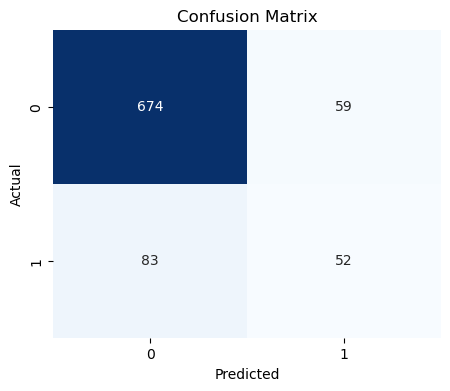

In [13]:
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, pred)

# Visualize confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cbar=False, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Key Insights & Recommendations
- At Risk segment: Shows the highest churn likelihood; prioritize these customers with targeted retention strategies.
- Champion segment: Very low churn; maintain loyalty through rewards and engagement programs.
- Average segment: Monitor behavior and apply upsell or cross-sell strategies to increase revenue.
- Evaluation insight: Model performs well overall, but lower churn recall indicates challenges due to class imbalance.
- Recommendation: Use segmentation and model insights to design targeted campaigns and improve customer retention.

In [19]:
rfm.to_csv("Final_data.csv", index=False)